# **MECS6616 Spring 2026 - Assignment 2: Imitation Learning**


***IMPORTANT:***
- **Before starting, make sure to read the [Assignment Instructions](https://courseworks2.columbia.edu/courses/237884/pages/assignment-instructions) page on Courseworks to understand the workflow and submission requirements for this project.**

***FOR Assignment 2!!!***
- Apart from the link to your notebook, you are also required to submit your chosen model checkpoint `.pth` files to Coursework. You will have one file for each part.
- Your part 2 files should be named `mlp_policy.pth` and `cvae_mlp_policy.pth`.
- You should put the link to your notebook in the "Comment" section of your submission.

# **Assignment Setup & Imports (do NOT change)**

***IMPORTANT:***
- Do NOT change this "*Assignment & Imports*" section
- Do NOT install any other dependencies or a different version of an already provided package. You may, however, import other packages

In [1]:
# ================================
# DO NOT MODIFY THIS CELL
# ================================
#
# This cell installs required system and Python dependencies.
# In particular, `dm_control` is installed to provide MuJoCo support.
# The installation may take a few seconds.
# Please run this cell before executing the rest of the notebook.

!apt-get install -qq -y libosmesa6-dev > /dev/null 2>&1
%pip install -q dm_control imageio imageio-ffmpeg


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 80.1 MB/s eta 0:00:00


In [2]:
# ================================
# DO NOT MODIFY THIS CELL
# ================================

import os
import time

# Use off-screen rendering for MuJoCo (headless environments like Colab)
os.environ['MUJOCO_GL'] = 'osmesa'


# ================================
# Core Imports
# ================================

import io
import base64
import copy
import math

import numpy as np
import imageio
import matplotlib.pyplot as plt

from dm_control import suite
from IPython.display import HTML, Video, clear_output
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split


# ================================
# Device Setup
# ================================

device = torch.device('cpu')


# ================================
# Visualization Utilities
# ================================

def show_video(frames, fps=30):
    """Display frames as an inline MP4 video."""
    buf = io.BytesIO()
    imageio.mimsave(buf, frames, format='mp4', fps=fps)
    buf.seek(0)

    b64 = base64.b64encode(buf.read()).decode()
    return HTML(
        f'<video controls autoplay loop>'
        f'<source src="data:video/mp4;base64,{b64}" type="video/mp4">'
        f'</video>'
    )


def visualize_log(ticks, rewards, frames, qposs, qvels):
    """Plot reward, positions, and velocities over time."""

    ticks = [t * 4 for t in ticks]

    fig, ax = plt.subplots(3, 3, sharex=True, figsize=(12, 8))

    qposs_array = np.asarray(qposs)
    qvels_array = np.asarray(qvels)

    # ========================
    # Row 1: Reward
    # ========================
    ax[0, 0].plot(ticks, rewards)
    ax[0, 0].set_ylabel('reward')
    ax[0, 0].set_title('Reward')

    ax[0, 1].axis('off')
    ax[0, 2].axis('off')

    # ========================
    # Row 2: Position
    # ========================
    ax[1, 0].plot(ticks, qposs_array[:, 0])
    ax[1, 0].set_ylabel('x position')
    ax[1, 0].set_title('X Position')

    ax[1, 1].plot(ticks, qposs_array[:, 1])
    ax[1, 1].set_ylabel('z position')
    ax[1, 1].set_title('Z Position')

    ax[1, 2].plot(ticks, qposs_array[:, 2])
    ax[1, 2].set_ylabel('pitch position')
    ax[1, 2].set_title('Pitch Position')

    # ========================
    # Row 3: Velocity
    # ========================
    ax[2, 0].plot(ticks, qvels_array[:, 0])
    ax[2, 0].set_ylabel('x velocity')
    ax[2, 0].set_xlabel('time')
    ax[2, 0].set_title('X Velocity')

    ax[2, 1].plot(ticks, qvels_array[:, 1])
    ax[2, 1].set_ylabel('z velocity')
    ax[2, 1].set_xlabel('time')
    ax[2, 1].set_title('Z Velocity')

    ax[2, 2].plot(ticks, qvels_array[:, 2])
    ax[2, 2].set_ylabel('pitch velocity')
    ax[2, 2].set_xlabel('time')
    ax[2, 2].set_title('Pitch Velocity')

    plt.tight_layout()
    plt.show()


# ================================
# PyTorch Activation Dictionary
# ================================

activation_dict = nn.ModuleDict({
    "ReLU": nn.ReLU(),
    "ELU": nn.ELU(),
    "GELU": nn.GELU(),
    "Tanh": nn.Tanh(),
    "Mish": nn.Mish(),
    "Identity": nn.Identity(),
    "Softplus": nn.Softplus(),
    "LeakyReLU": nn.LeakyReLU(),
    "Sigmoid": nn.Sigmoid(),
})


## **Vital Code Explanation for MPC Environment**

This is the same environment wrapper (`MPC_ENV_GT`) introduced in Assignment 1.  
It allows MPC to operate at a lower control frequency by internally managing interactions with the original `dm_control` environment.

Instead of stepping the simulator at its native timestep, this wrapper:

- Repeats each action multiple times  
- Accumulates intermediate rewards  
- Exposes a lower control frequency for MPC  

This design better reflects realistic control settings and reduces computational cost during planning.

You are **not allowed to modify any code** in this class.

---

### Additional Functions

In this assignment, we additionally provide two utility functions:

- `apply_force(force, ...)`  
  Applies an external force (and optionally torque) to the cheetah, allowing you to introduce perturbations into the environment.

- `clear_forces()`  
  Removes all externally applied forces and torques.

These functions are **not required** for this assignment. However, you are encouraged to experiment with them during testing.

Introducing perturbations can help you observe how your controller behaves under **out-of-distribution (OOD)** states, and provides insight into why methods such as imitation learning may fail when the system deviates from the training distribution.

Further details on how to use these functions will be provided later.

In [3]:
# ================================
# DO NOT MODIFY THIS CELL
# ================================

class MPC_ENV_GT:
    def __init__(self, env):
        self.env = env
        self.action_spec = env.action_spec()

        self.MPC_frequency = 25
        self.control_timestep = 1/self.MPC_frequency
        self.MPC_repeats = int(self.control_timestep/env.control_timestep())

        self.clear()

    def clear(self):
        # Initialize data collection lists
        self.frames = []  # Store rendered frames for video
        self.qposs = []  # Store states of the cheetah
        self.qvels = []  # Store velocities of the cheetah

    def reset(self):
        self.env.reset()

    def get_state(self):
        return self.env.physics.get_state()

    def set_state(self, state):
        self.env.physics.set_state(state)
        self.env.physics.forward()

    def step(self, action, record=False):
        reward = 0.0
        for _ in range(self.MPC_repeats):
            time_step = self.env.step(action)
            reward += time_step.reward
        if record:
          self.frames.append(self.env.physics.render(camera_id=0, width=256, height=256))
          self.qposs.append(copy.deepcopy(self.env.physics.data.qpos))
          self.qvels.append(copy.deepcopy(self.env.physics.data.qvel))
        return reward

    def get_log(self):
        return self.frames, self.qposs, self.qvels

    def apply_force(self, force, body_name='torso', magnitude=50.0, apply_torque=False):
        body_id = self.env.physics.model.name2id(body_name, 'body')
        self.env.physics.data.xfrc_applied[:] = 0.0
        self.env.physics.data.xfrc_applied[body_id, :3] = force
        if apply_torque:
            torque = np.random.uniform(-magnitude * 0.1, magnitude * 0.1, size=3)
            self.env.physics.data.xfrc_applied[body_id, 3:] = torque
        return force

    def clear_forces(self):
        """Zero out all external forces/torques."""
        self.env.physics.data.xfrc_applied[:] = 0.0

    def close(self):
        self.env.close()


## **Normalizer Definition**

We provide you with the Mini-Max Normalizer Class  for the model training. **DO NOT CHANGE IT.**

In [4]:
# ================================
# DO NOT MODIFY THIS CELL
# ================================

class MiniMaxStateActionNormalizer:
    """Normalizer for states and actions using min-max scaling."""

    def __init__(self, normalization_range=(-1, 1)):
        """
        Initialize normalizer.

        Args:
            normalization_range: Tuple of (min, max) for normalization.
                                 Use (-1, 1) or (0, 1)
        """
        self.normalization_range = normalization_range

        self.state_min = None
        self.state_max = None
        self.action_min = None
        self.action_max = None
        self.next_state_min = None
        self.next_state_max = None

    def fit(self, states, actions, next_states=None):
        """
        Compute normalization statistics from training data.

        Args:
            states: numpy array or torch tensor (N, state_dim)
            actions: numpy array or torch tensor (N, action_dim)
            next_states: optional, numpy array or torch tensor (N, state_dim)
        """
        if isinstance(states, np.ndarray):
            states = torch.FloatTensor(states)
        if isinstance(actions, np.ndarray):
            actions = torch.FloatTensor(actions)

        # Compute min and max for states
        self.state_min = states.min(dim=0)[0]
        self.state_max = states.max(dim=0)[0]

        # Add small epsilon to avoid division by zero
        self.state_max = torch.maximum(self.state_max, self.state_min + 1e-8)

        # Compute min and max for actions
        self.action_min = actions.min(dim=0)[0]
        self.action_max = actions.max(dim=0)[0]

        # Add small epsilon to avoid division by zero
        self.action_max = torch.maximum(self.action_max, self.action_min + 1e-8)

        # Optionally compute min and max for next_states
        if next_states is not None:
            if isinstance(next_states, np.ndarray):
                next_states = torch.FloatTensor(next_states)
            self.next_state_min = next_states.min(dim=0)[0]
            self.next_state_max = next_states.max(dim=0)[0]
            self.next_state_max = torch.maximum(self.next_state_max, self.next_state_min + 1e-8)
        else:
            # Use same stats as states
            self.next_state_min = self.state_min
            self.next_state_max = self.state_max

    def normalize_state(self, state):
        """
        Normalize state to [normalization_range].

        Formula: x_norm = (x - min) / (max - min) * (range_max - range_min) + range_min
        """
        # Scale to [0, 1]
        state_01 = (state - self.state_min) / (self.state_max - self.state_min)

        # Scale to [normalization_range]
        range_min, range_max = self.normalization_range
        state_norm = state_01 * (range_max - range_min) + range_min

        return state_norm

    def normalize_action(self, action):
        """Normalize action to [normalization_range]."""
        # Scale to [0, 1]
        action_01 = (action - self.action_min) / (self.action_max - self.action_min)

        # Scale to [normalization_range]
        range_min, range_max = self.normalization_range
        action_norm = action_01 * (range_max - range_min) + range_min

        return action_norm

    def normalize_state_action(self, state, action):
        """Normalize and concatenate state and action."""
        state_norm = self.normalize_state(state)
        action_norm = self.normalize_action(action)
        return torch.cat([state_norm, action_norm], dim=-1)

    def normalize_next_state(self, next_state):
        """Normalize next state to [normalization_range]."""
        # Scale to [0, 1]
        next_state_01 = (next_state - self.next_state_min) / (self.next_state_max - self.next_state_min)

        # Scale to [normalization_range]
        range_min, range_max = self.normalization_range
        next_state_norm = next_state_01 * (range_max - range_min) + range_min

        return next_state_norm

    def denormalize_state(self, state_norm):
        """Denormalize state back to original scale."""
        # Scale from [normalization_range] to [0, 1]
        range_min, range_max = self.normalization_range
        state_01 = (state_norm - range_min) / (range_max - range_min)

        # Scale from [0, 1] to original range
        state = state_01 * (self.state_max - self.state_min) + self.state_min

        return state

    def denormalize_action(self, action_norm):
        """Denormalize action back to original scale."""
        # Scale from [normalization_range] to [0, 1]
        range_min, range_max = self.normalization_range
        action_01 = (action_norm - range_min) / (range_max - range_min)

        # Scale from [0, 1] to original range
        action = action_01 * (self.action_max - self.action_min) + self.action_min

        return action

    def denormalize_next_state(self, next_state_norm):
        """Denormalize next state back to original scale."""
        # Scale from [normalization_range] to [0, 1]
        range_min, range_max = self.normalization_range
        next_state_01 = (next_state_norm - range_min) / (range_max - range_min)

        # Scale from [0, 1] to original range
        next_state = next_state_01 * (self.next_state_max - self.next_state_min) + self.next_state_min

        return next_state

    def save(self, path):
        """Save normalization statistics."""
        torch.save({
            'normalization_range': self.normalization_range,
            'state_min': self.state_min,
            'state_max': self.state_max,
            'action_min': self.action_min,
            'action_max': self.action_max,
            'next_state_min': self.next_state_min,
            'next_state_max': self.next_state_max,
        }, path)

    def load(self, path):
        """Load normalization statistics."""
        checkpoint = torch.load(path)
        self.normalization_range = checkpoint['normalization_range']
        self.state_min = checkpoint['state_min']
        self.state_max = checkpoint['state_max']
        self.action_min = checkpoint['action_min']
        self.action_max = checkpoint['action_max']
        self.next_state_min = checkpoint['next_state_min']
        self.next_state_max = checkpoint['next_state_max']

print("Normalizer defined")


Normalizer defined


## **Dataset Definition**

We provide you with the Dataset class for the model training.  **You can modify it, but theoretically, there is no need to do so.**

In [5]:
# ================================
# DO NOT MODIFY THIS CELL
# ================================

"""
==============
Dataset for Action Chunking Transformer (ACT).

Loads from the assembled dataset.npz produced by assemble_data.py.
The .npz already contains pre-chunked data:
    states        : (N, state_dim)
    action_chunks : (N, prediction_horizon, action_dim)  <- executed actions only, chunked

Each sample:
    X : state        (state_dim,)
    Y : action_chunk (prediction_horizon, action_dim)

Since all actions in the chunk are real executed actions, they share the same
behavioral distribution across horizon steps. A single shared (min, max) per
action dimension is therefore used — no per-step normalisation needed.
"""

class Cheetah_Dataset(Dataset):
    """
    Parameters
    ----------
    datafile : str
        Path to the assembled .npz file (output of assemble_data.py).
    normalizer : MiniMaxStateActionNormalizer or None
    fit_normalizer : bool
        If True, fit and save the normalizer on this dataset.
    normalizer_save_path : str
    state_dim : int   (default 18)
    action_dim : int  (default 6)
    """

    def __init__(
        self,
        datafile,
        normalizer=None,
        fit_normalizer=False,
        normalizer_save_path='act_normalizer.pt',
        state_dim=18,
        action_dim=6,
    ):
        d = np.load(datafile, allow_pickle=True)

        self.states  = d['states'].astype(np.float32)        # (N, state_dim)
        self.actions = d['action_chunks'].astype(np.float32) # (N, prediction_horizon, action_dim)

        self.state_dim  = state_dim
        self.action_dim = action_dim
        self.prediction_horizon  = self.actions.shape[1]              # prediction_horizon
        self.normalizer = normalizer

        print(f'Cheetah_Dataset loaded: {len(self.states):,} samples  '
              f'state_dim={state_dim}  prediction_horizon={self.prediction_horizon}  action_dim={action_dim}')

        # ── Fit normalizer ────────────────────────────────────────────
        # Flatten (N, prediction_horizon, action_dim) -> (N * prediction_horizon, action_dim)
        # so the normalizer sees all executed actions and fits one shared
        # (min, max) per action dimension across all horizon steps.
        if fit_normalizer and normalizer is not None:
            actions_flat = self.actions.reshape(-1, action_dim)  # (N * prediction_horizon, action_dim)
            print('Fitting normalizer on training data ...')
            normalizer.fit(
                torch.FloatTensor(self.states),
                torch.FloatTensor(actions_flat),
            )
            normalizer.save(normalizer_save_path)
            print(f'Normalizer saved to {normalizer_save_path}')

    def __len__(self):
        return len(self.states)

    def __getitem__(self, idx):
        state  = torch.FloatTensor(self.states[idx]).unsqueeze(0)  # (1, state_dim)
        action = torch.FloatTensor(self.actions[idx])               # (prediction_horizon, action_dim)

        if self.normalizer is not None:
            state  = self.normalizer.normalize_state(state)
            # Shared (min, max) per action dim — broadcast over prediction_horizon automatically
            action = self.normalizer.normalize_action(action)  # (prediction_horizon, action_dim)
        x = {"obs":state,"action":action}
        return x


## **Receding-Horizon Control**
Similar to the MPC framework, we apply *receding-horizon control* in this assignment as follows: At each time step $t$, the policy takes the most recent $T_o$ steps of observation data $O_t$ as input, and predicts $T_a$ steps of future actions $A_t$. This stratetgy is illustrated in the Diffusion Policy paper as follows:

<div>
<img src="https://github.com/roamlab/mece6616_sp25_project4/blob/main/imgs/receding.png?raw=true" width="300"/>
</div>

**Important**: In the cheetah task implementation we use, the horizon of actions prediction in the dataset (10) can differ from the horizon of actions prediction used in training. Similarly, the horizon of actions predicted by the agent can differ from the number of actions actually executed during inference.

**Clarification**
: Usually, observation differs from state. However, we assume we have direct observations of all the states in this problem and use them interchangeably in this assignment.

**Please upload the dataset file `dataset_no_perturbation.npz` attached to the Assignment Description on Canvas to Colab.**

In [6]:
normalizer = MiniMaxStateActionNormalizer()
dataset = Cheetah_Dataset(
    datafile='dataset_no_perturbation.npz',
    normalizer=None,
    fit_normalizer=False,
    state_dim=18,
    action_dim=6,
)
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=256,
    num_workers=1,
    shuffle=True,
    # accelerate cpu-gpu transfer
    pin_memory=True,
    # don't kill worker process afte each epoch
    persistent_workers=True
)
# visualize data in batch
batch = next(iter(dataloader))
print("batch['obs'].shape:", batch['obs'].shape)
print("batch['action'].shape", batch['action'].shape)


Cheetah_Dataset loaded: 20,000 samples  state_dim=18  prediction_horizon=10  action_dim=6


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


batch['obs'].shape: torch.Size([256, 1, 18])
batch['action'].shape torch.Size([256, 10, 6])


# **Part I Vanilla Imitation Learning using MLP**
In this setting, we will implement a vanilla Imitation Learning agent using a simple Multi-Layer Perceptron (MLP) with residual connection. The MLP agent takes as input an observation sequence of length $T_o$ (set as 1 in the cheetah task, can be >1 in other task), which represents the most recent $T_o$  timesteps of the state data. Based on this input, the agent predicts an action sequence of length $T_a$ (set as 6 in the Push-T task), which corresponds to the next $T_a$ steps the agent intends to take in the environment.

Mathematically, the policy is represented as: $\pi(a_{t:t+T_a} \mid o_{t-T_o:t})$

<div>
<img src="https://github.com/roamlab/mece6616_sp25_project4/blob/main/imgs/mlp_agent.png?raw=true" width="400"/>
</div>

## **Model Architecture Definition**

In this section, you are required to implement an **MLP-based vanilla imitation learning model**.

The goal is to learn a policy that directly maps:

$$\text{state}_t \rightarrow \text{action}_{t:t+n}$$

i.e., given the current state, the model predicts a sequence of future actions over a horizon.

---

### Model Design

You are expected to implement an MLP that serves as a function approximator for this mapping.

You are free to modify or extend the parameters in the `__init__` function, including but not limited to:

- Hidden layer sizes  
- Number of layers  
- Activation functions  
- Dropout or normalization layers  

---

### Objective

The model should learn to imitate expert demonstrations by minimizing the difference between predicted and ground-truth action sequences.


In [7]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
class MLP(nn.Module):
# ================================
# YOUR CODE GOES HERE
    def __init__(
        self,
        state_dim: int = 18,
        state_horizon: int = 1,
        action_dim: int = 6,
        prediction_horizon: int = 6,
        dim_list: list = None,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.state_dim  = state_dim
        self.action_dim = action_dim
        self.prediction_horizon  = prediction_horizon
        in_dim = state_dim * state_horizon
        out_dim = prediction_horizon * action_dim

        hidden_dims = dim_list if dim_list is not None else [256, 256, 256]
        dims = [in_dim] + hidden_dims + [out_dim]
        layers = []
        for i in range(len(dims) - 2):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)


# ================================

    def forward(self, state):
# ================================
# YOUR CODE GOES HERE

        if state.dim() > 2:
            state = state.flatten(start_dim=1)
        action_seq = self.net(state)
        return action_seq
# ================================


## **Training Function Definition**

We provide you with the train and test functions for the model training. **You can modify it, but theoretically, there is no need to do so.**

**For imitation learning, you might want to utilize your dataset as much as possible, and a validation set might not be needed. However, we still provide you with the `test` function in case you need it.**

In [8]:
import tqdm
import pickle
import time
import shutil
import os
import numpy as np

def train(model, loader, optimizer, criterion, state_horizon, prediction_horizon, device):
    model.train()
    total_loss = 0.0
    for nbatch in loader:
        state = nbatch['obs'].to(device)[:, :state_horizon, :]
        action_seq = nbatch['action'].to(device)[:, :prediction_horizon, :]

        optimizer.zero_grad()
        pred = model(state.flatten(start_dim=1))
        loss = criterion(pred.flatten(start_dim=1), action_seq.flatten(start_dim=1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def test(model, loader, criterion, state_horizon, prediction_horizon, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
      for nbatch in loader:
            state = nbatch['obs'].to(device)
            action_seq = nbatch['action'].to(device)[:, :prediction_horizon, :]
            pred = model(state.flatten(start_dim=1))
            loss = criterion(pred.flatten(start_dim=1), action_seq.flatten(start_dim=1))
            total_loss += loss.item()
    return total_loss / len(loader)

print("Training functions defined")


Training functions defined


## **Train the Vinalla Policy**
In this section, you will instantiate your `Vinalla Imitation Learning Policy` and train it using the collected transition dataset.

You are free to design the training procedure. This includes, but is not limited to:

- Train/validation split ratio **For imitation learning, you might want to utilize your dataset as much as possible, and a validation set might not be needed.**
- Predition Horizon
- Batch size  
- Choice of loss function  
- Optimizer type and hyperparameters  
- Learning rate  
- Learning rate scheduler type
- Number of training epochs  
- Model selection strategy (e.g., best validation loss)

Your goal is to learn an accurate policy that maps state to action sequence:

    (state_t) → action {t:t+n}

For evaluation, consider monitoring both training and validation losses to avoid overfitting. A well-trained policy model should achieve low one-step prediction error.

---

Theoretically, **20 minutes** are enough for this part.

In [9]:
#@title{vertical-output: true}

import shutil
# ================================
# Do NOT change - We are only using CPU, and GPU is not allowed.
device = torch.device("cpu")
# ================================


# ================================
# YOUR CODE GOES HERE
state_dim = 18
action_dim = 6
state_horizon = 1
prediction_horizon = 1

batch_size = 512
lr = 3e-4
epochs = 200

# ================================
# Do NOT change, for skipping training in grading
normalizer = MiniMaxStateActionNormalizer()
dataset = Cheetah_Dataset(
    datafile='dataset_no_perturbation.npz',
    normalizer=normalizer,
    fit_normalizer=True,
    state_dim=state_dim,
    action_dim=action_dim,
)
model_path = 'mlp_policy.pth'
if os.path.exists(model_path):
    print(f"Model already exists at {model_path}, skipping training.")
# ================================

else:

    dataset_size = len(dataset)
    torch.manual_seed(42)
    generator = torch.Generator().manual_seed(42)

    train_loader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=True, generator=generator
    )

    timestr = time.strftime("%Y-%m-%d_%H-%M-%S")
    model_dir = os.path.join('models', timestr)
    if not os.path.isdir(model_dir):
        os.makedirs(model_dir)

    model = MLP(
        state_dim=state_dim,
        state_horizon=state_horizon,
        action_dim=action_dim,
        prediction_horizon=prediction_horizon,
        ).to(device)

    print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

    criterion = nn.SmoothL1Loss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_model_path = None
    best_train_loss = float('inf')

    for epoch in range(1, 1 + epochs):
        train_loss = train(model, train_loader, optimizer, criterion, state_horizon, prediction_horizon, device)
        if train_loss < best_train_loss:
            best_train_loss = train_loss
            best_model_path = os.path.join(model_dir, 'best_mlp_policy.pth')
            torch.save(model.state_dict(), best_model_path)
        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(f"Epoch {epoch:03d}/{epochs} | train_loss={train_loss:.6f}")

    shutil.copy(best_model_path, model_path)
# ================================
    print(f"\nTraining complete! Best model saved to: {model_path}")


Cheetah_Dataset loaded: 20,000 samples  state_dim=18  prediction_horizon=10  action_dim=6
Fitting normalizer on training data ...
Normalizer saved to act_normalizer.pt
Model already exists at mlp_policy.pth, skipping training.


## **VanillaAgent for Policy Execution**

We provide a `VanillaAgent` class to handle model loading, normalization, and action generation.

This class wraps your trained policy model and exposes a `plan` function that maps the current state to a sequence of actions.

You are **not allowed to modify any code** in this class, except for the model definition inside the designated section (`YOUR CODE GOES HERE ONLY`).

---

### Important Notes

- The agent automatically:
  - Loads the state-action normalizer
  - Normalizes inputs before inference
  - Denormalizes predicted actions before returning

- The `plan` function outputs a sequence of actions with length equal to `prediction_horizon`.

- During execution, only the first `execution_horizon` actions may be applied before replanning.

---

### Flexibility

When instantiating the agent, you are allowed to modify:

- `prediction_horizon`
- `execution_horizon`

Different choices may affect performance, especially in terms of stability and robustness.

Please ensure that your model architecture matches the saved checkpoint (`model_path`), otherwise loading will fail.

In [10]:
# ================================
# DO NOT MODIFY THIS CELL (EXCEPT FOR MODEL INSTANTIATION)
# ================================

class VanillaAgent:
    def __init__(self, normalizer_path, model_path, state_dim = 18, state_horizon = 1, action_dim = 6, prediction_horizon = 1, execution_horizon = 1):
        self.state_dim = state_dim
        self.state_horizon = state_horizon
        self.action_dim = action_dim
        self.prediction_horizon = prediction_horizon
        self.execution_horizon = execution_horizon

        self.device = torch.device('cpu')
        self.normalizer = MiniMaxStateActionNormalizer()
        self.normalizer.load(normalizer_path)
        print(f'Normalizer loaded from {normalizer_path}')

        # ================================
        # YOUR CODE GOES HERE ONLY
        self.model = MLP(
                    state_dim=self.state_dim,
                    state_horizon=self.state_horizon,
                    action_dim=self.action_dim,
                    prediction_horizon=self.prediction_horizon,
                    ).to(device)
        # ================================

        state_dict = torch.load(model_path, map_location=self.device)
        self.model.load_state_dict(state_dict)
        self.model.eval()
        print(f'Model loaded from {model_path}  '
              f'(params: {sum(p.numel() for p in self.model.parameters()):,})')

    def plan(self, current_state, denormalize = True):
        current_state = torch.FloatTensor(current_state).unsqueeze(0).to(self.device)
        state_norm = self.normalizer.normalize_state(current_state).unsqueeze(0)

        with torch.no_grad():
            action_norm = self.model(state_norm)

        action_norm = action_norm.view(1, self.prediction_horizon, self.action_dim)
        action_norm = action_norm.squeeze(0)

        if denormalize:
            action = self.normalizer.denormalize_action(action_norm)
            return action.numpy()
        else:
            return action_norm.numpy()


## **Manual Testing and Visualization**

Similar to Assignment 1, we provide a visualization script to help you evaluate the performance of your trained policy.

The script runs a rollout in the environment, records rewards, states, and rendered frames, and visualizes them for analysis.

---

### External Disturbance (Optional)

Inside the simulation loop, there is a commented-out code block that applies external forces to the cheetah:

- This uses the `apply_force` and `clear_forces` functions provided in the environment.
- Although this is **not required** for this assignment, you are encouraged to experiment with it.

By adjusting:
- Force magnitude  
- Application interval  
- Duration  

you can observe how your policy behaves under external perturbations.

This is particularly useful for understanding how imitation learning methods may fail under **out-of-distribution (OOD)** conditions, where the system deviates from the training data distribution.

---

### Important Note

To reduce grading time, **please comment out the entire testing/visualization block in your final submission**.


Normalizer loaded from act_normalizer.pt
Model loaded from mlp_policy.pth  (params: 137,990)
Step 0/100, total reward: 0.11, avg reward: 0.1122
Step 10/100, total reward: 6.77, avg reward: 0.6158
Step 20/100, total reward: 21.11, avg reward: 1.0052
Step 30/100, total reward: 38.32, avg reward: 1.2361
Step 40/100, total reward: 47.28, avg reward: 1.1532
Step 50/100, total reward: 55.71, avg reward: 1.0923
Step 60/100, total reward: 58.17, avg reward: 0.9537
Step 70/100, total reward: 58.19, avg reward: 0.8195
Step 80/100, total reward: 58.19, avg reward: 0.7184
Step 90/100, total reward: 58.19, avg reward: 0.6395
100 frames, total reward: 58.19, avg reward: 0.5819


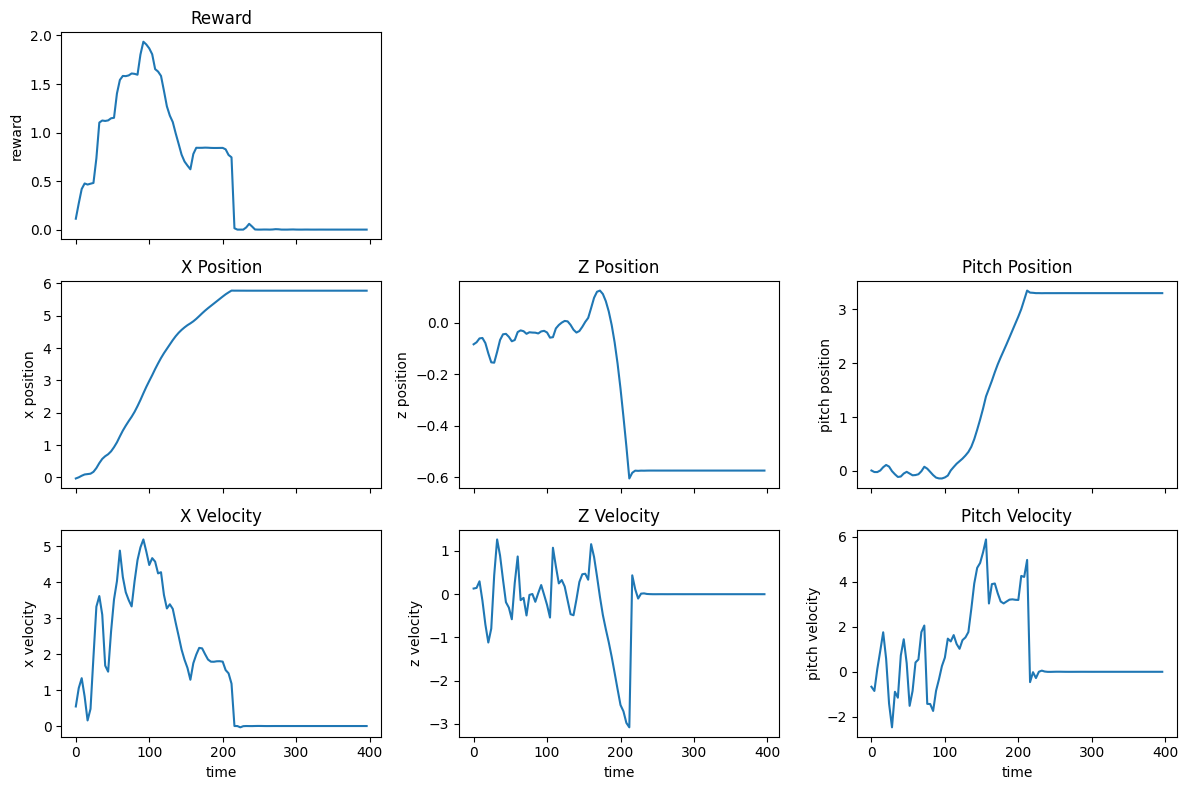

In [11]:
#@title {vertical-output: true}
import copy
import matplotlib.pyplot as plt

random_state = np.random.RandomState(42)
np.random.seed(42)
env = MPC_ENV_GT(suite.load('cheetah', 'run', task_kwargs={'random': random_state}))

# Set simulation duration and calculate number of steps
duration = 4.0  # seconds
num_steps = int(duration / env.control_timestep)


# ================================
# AGENT INSTANTIATION
mpc_agent = VanillaAgent('act_normalizer.pt','mlp_policy.pth', prediction_horizon=1)

# ================================

rewards = []
ticks = []
action_sequence = []
env.reset()
active_force_until = -1

# Main simulation loop
for step in range(num_steps):
    # if step % 20 == 10:
    #     force = env.apply_force(
    #                   body_name='torso',
    #                   force=[100,0,],
    #                   apply_torque=False,
    #                   )
    #     active_force_until = step + 5
    # if step == active_force_until:
    #     env.clear_forces()


    # Plan: Get best action sequence via MPC and take first action
    current_state = env.get_state()

    if len(action_sequence) == 0:
      action_sequence = mpc_agent.plan(current_state)[:mpc_agent.execution_horizon]
    action, action_sequence = action_sequence[0], action_sequence[1:]

    # Execute: Apply action to environment
    reward = env.step(action,True)

    # Record: Collect data from this step
    rewards.append(reward)
    ticks.append(step)

    # Print progress every 10 steps
    if step % 10 == 0:
        print(f"Step {step}/{num_steps}, total reward: {sum(rewards):.2f}, avg reward: {np.mean(rewards):.4f}")

frames, qposs, qvels = env.get_log()
print(f"{len(frames)} frames, total reward: {sum(rewards):.2f}, avg reward: {np.mean(rewards):.4f}")
visualize_log(ticks, rewards, frames, qposs, qvels)

env.close()
# Display video of the cheetah running
show_video(frames, fps=25)


## **Grading and Evaluation for Part 1**

Your trained policy will be evaluated over **100 independent episodes**, each consisting of a **4-second rollout**.

In each episode:

- The environment is initialized with a different random seed.
- Your controller generates actions using the learned policy.
- The accumulated reward over the episode is recorded.

---

### Stability Penalty

If the cheetah falls during an episode (i.e., the torso pitch angle exceeds the threshold):

- The reward for that episode will be **penalized**.
- The number of such failures will also be recorded.

---

### Final Score

After all 100 episodes:

- The **average penalized reward** is computed.
- Your final score is determined based on the following thresholds:

  - Average reward ≥ 80 → **2 points**
  - Average reward ≥ 40 → **1 point**
  - Average reward < 40 → **0 points**

---

This evaluation emphasizes not only performance but also **robustness across different initial conditions**. Controllers that are unstable or sensitive to distribution shifts will receive lower scores.

Except for the line:

    mpc_agent = VanillaAgent('act_normalizer.pt','mlp_policy.pth')

you are **not allowed to modify any other code in the evaluation cell**.

In [12]:
#@title{vertical-output: true}
import copy
import time
import matplotlib.pyplot as plt

# Set simulation duration and calculate number of steps
duration = 4.0  # seconds


# Instantiate your Agent controller
# but do NOT modify anything else in this cell.
# ================================
# YOUR CODE GOES HERE ONLY
mpc_agent = VanillaAgent('act_normalizer.pt','mlp_policy.pth', prediction_horizon=1)
# ================================

rewards = []
flipped_count = 0

for i in range(100):

  random_state = np.random.RandomState(i+200)
  np.random.seed(i)
  env = MPC_ENV_GT(suite.load('cheetah', 'run', task_kwargs={'random': random_state}))
  env.reset()

  num_steps = int(duration / env.control_timestep)
  reward = 0.0
  flipped = False

  action_sequence = []
  for step in range(num_steps):
      current_state = env.get_state()

      # ---- Fall detection (pitch angle) ----
      if abs(current_state[2]) > np.pi / 2:
          flipped = True

      if len(action_sequence) == 0:
        action_sequence = mpc_agent.plan(current_state)[:mpc_agent.execution_horizon]
      action, action_sequence = action_sequence[0], action_sequence[1:]
      r = env.step(action)

      reward += r

  env.close()
  if flipped:
    reward = reward/2.0
    flipped_count += 1
  else:
    reward = reward
  print(f"Episode {i+1} reward: {reward:.2f}", flipped)
  rewards.append(reward)

avg_reward = np.mean(rewards)
print(f"Average penalized reward: {avg_reward:.2f} with {str(flipped_count)} times flipping")

# Reward score
if avg_reward >= 80:
    final_score_part1 = 2
elif avg_reward >= 40:
    final_score_part1 = 1
else:
    final_score_part1 = 0

print(f"Score for Part1: {final_score_part1}/2")


Normalizer loaded from act_normalizer.pt
Model loaded from mlp_policy.pth  (params: 137,990)
Episode 1 reward: 82.78 True
Episode 2 reward: 187.22 False
Episode 3 reward: 168.98 False
Episode 4 reward: 163.97 False
Episode 5 reward: 196.57 False
Episode 6 reward: 171.23 False
Episode 7 reward: 187.49 False
Episode 8 reward: 127.57 False
Episode 9 reward: 184.94 False
Episode 10 reward: 170.11 False
Episode 11 reward: 144.63 False
Episode 12 reward: 182.14 False
Episode 13 reward: 192.70 False
Episode 14 reward: 51.44 True
Episode 15 reward: 173.96 False
Episode 16 reward: 145.92 False
Episode 17 reward: 162.35 False
Episode 18 reward: 183.24 False
Episode 19 reward: 175.81 False
Episode 20 reward: 200.90 False
Episode 21 reward: 44.56 True
Episode 22 reward: 165.31 False
Episode 23 reward: 193.52 False
Episode 24 reward: 202.34 False
Episode 25 reward: 26.36 True
Episode 26 reward: 37.37 True
Episode 27 reward: 68.19 True
Episode 28 reward: 173.50 False
Episode 29 reward: 45.41 True
Ep

# **Part 2. Behavioral Cloning with CVAE Agent**

In the second part, we frame behavioral cloning as a conditional generative modeling task, where the goal is to generate action sequences conditioned on observed states. To achieve this, we adopt a **Conditional Variational Autoencoder (CVAE)** agent, which consists of two components: an encoder and a decoder.

The CVAE encoder is used only during training. It takes as input the current observation sequence $o_{t-T_o:t}$ and the corresponding expert action sequence $\bar{a}_{t:t+T_a}$, and outputs the mean and variance of a latent “style” variable $z$. This latent variable captures variations in the demonstrated behavior and is modeled as a multivariate diagonal Gaussian.

To regularize the latent space, we apply a **KL divergence loss** that encourages the distribution of $z$ to match a standard normal distribution $N(0, I)$. This helps prevent the latent representation from collapsing to deterministic values and enables meaningful sampling at inference time. The encoder is discarded during testing.

The CVAE decoder serves as the actual policy. It conditions on both the latent variable $z$ and the current observation sequence $o_{t-T_o:t}$ to predict the action sequence $a_{t:t+T_a}$. At test time, we typically set $z=0$ to perform deterministic decoding.


Mathematically,

*   **CVAE Encoder:** $q_{\phi}(z \mid \bar{a}_{t:t+T_a}, o_{t-T_o:t})$
*   **CVAE Decoder:** $\pi_{\theta}(a_{t:t+T_a} \mid o_{t-T_o:t}, z)$

<div>
<img src="https://github.com/roamlab/mece6616_sp25_project4/blob/main/imgs/cvae_agent.png?raw=true" width="600"/>
</div>

## Conditional Variational Autoencoder (CVAE): Encoder & Decoder

In this section, you are required to implement a **CVAE-based imitation learning model**.

Unlike the previous MLP policy, CVAE introduces a **latent variable** to model the stochasticity and multi-modality of expert behaviors.

---

### Overall Idea

The model learns a conditional distribution by introducing a latent variable $ z \sim \mathcal{N}(\mu, \sigma^2) $.

---

### Encoder

The encoder takes as input:

- State sequence
- Action sequence

and outputs a Gaussian distribution:

- Mean $ \mu $
- Log-variance $ \log \sigma^2 $

$$(\mu, \log \sigma^2) = q_{\phi}(z \mid \bar{a}_{t:t+T_a}, o_{t-T_o:t})$$


This distribution represents the posterior over latent variables conditioned on expert demonstrations.

---

### Decoder

The decoder generates the action sequence conditioned on:

- State sequence
- Sampled latent variable $ z \sim \mathcal{N}(\mu, \sigma^2) $

$$\hat{a}_{t:t+T_a} = \pi_{\theta}(a_{t:t+T_a} \mid o_{t-T_o:t}, z)$$

The latent variable is sampled from the encoder distribution during training, and combined with the state before being passed into the decoder.

---

### Implementation Requirement

You are required to implement both:

- `Encoder`
- `Decoder`

using MLP-based architectures.

Note that:

- You are free to modify or extend the parameters in the `__init__` function as needed (e.g., hidden size, number of layers, activation functions, etc.).
- The encoder must output a valid Gaussian distribution parameterization.
- The decoder must reconstruct the full action sequence from latent + state.

---

### Key Intuition

- Encoder: compresses demonstration into a latent “skill embedding”
- Decoder: reconstructs expert action sequence conditioned on state and skill
- Latent space enables modeling **multi-modal expert behaviors**

In [13]:
from collections import OrderedDict
# ================================
# YOUR CODE GOES HERE

class Encoder(nn.Module):
    def __init__(
        self,
        dim_list,
        state_dim,
        state_horizon,
        action_dim,
        prediction_horizon,
        latent_dim,
    ):
        super(Encoder, self).__init__()
        input_dim = state_horizon * state_dim + prediction_horizon * action_dim

        dims = [input_dim, 512, 512, 512]
        layers = []
        for i in range(len(dims)-1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(nn.LeakyReLU(0.2))
        self.net = nn.Sequential(*layers)
        self.fc_mu = nn.Linear(512, latent_dim)
        self.fc_logvar = nn.Linear(512, latent_dim)

    def forward(self, obs, action):
        x = torch.cat([obs, action], dim=1)

        feat = self.net(x)
        mu = self.fc_mu(feat)
        logvar = self.fc_logvar(feat)

        return mu, logvar



class Decoder(nn.Module):
    def __init__(
        self,
        dim_list,
        state_dim,
        state_horizon,
        action_dim,
        prediction_horizon,
        latent_dim,
    ):
        super(Decoder, self).__init__()
        input_dim = state_horizon * state_dim + latent_dim

        dims = [input_dim, 512, 512, 512]
        layers = []
        for i in range(len(dims)-1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(nn.LeakyReLU(0.2))
        layers.append(nn.Linear(512, prediction_horizon * action_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, obs, z):
        x = torch.cat([obs, z], dim=1)

        action = self.net(x)

        return action

# ================================


## Conditional Variational Autoencoder (CVAE)

In this section, you are required to complete the full **CVAE model**, including the initialization of the encoder/decoder and the implementation of inference and training forward pass.

---

## Implementation Requirements

You must complete the following parts:

### 1. Initialization (`__init__`)
You should instantiate:

- `Encoder`
- `Decoder`

You are allowed to modify the initialization structure if needed, as long as the encoder and decoder are correctly constructed.

---

### 2. Inference (`sample_action`)

During inference:

- No stochastic sampling from the encoder is used
- The latent variable is set to:
  $z = 0$

- The model outputs only the predicted action sequence

This ensures deterministic policy execution at test time.

---

### 3. Training Forward Pass (`forward`)

During training:

- The encoder outputs:
  - mean $\mu$
  - log-variance $\log \sigma^2$

- A latent variable is sampled using the **reparameterization trick**: $ z \sim \mathcal{N}(\mu, \sigma^2) $

- The decoder reconstructs the action sequence conditioned on:
  - state
  - sampled latent variable

The function must return:

- `mu`
- `logvar`
- `action_pred`

These are used to compute:
- reconstruction loss
- KL divergence loss

---

## Key Intuition

- Encoder learns a distribution over latent “skills”
- Decoder reconstructs action sequences conditioned on state + latent code
- Latent space enables multi-modal imitation and better generalization

In [14]:
class CVAE(nn.Module):
    def __init__(
        self,
        encoder_dim_list,
        decoder_dim_list,
        state_dim,
        state_horizon,
        action_dim,
        prediction_horizon,
        latent_dim,
    ):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim

        # ================================
        # YOUR CODE GOES HERE
        encoder_dim_list = [512, 512, 512]
        self.encoder = Encoder(
            encoder_dim_list,
            state_dim,
            state_horizon,
            action_dim,
            prediction_horizon,
            latent_dim
        )
        decoder_dim_list = [512, 512, 512]
        self.decoder = Decoder(
            decoder_dim_list,
            state_dim,
            state_horizon,
            action_dim,
            prediction_horizon,
            latent_dim)
        # ================================

    def reparameterize(self, mu, logvar):
        # Enables backpropagation through a stochastic sampling process
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def sample_action(self, obs):
        # TODO: complete the inference function
        # Hint:
        # 1. Set embedding z as 0 during the inference time
        # 2. Only return action sequence

        # ================================
        # YOUR CODE GOES HERE


        batch_size = obs.size(0)
        z = torch.zeros(batch_size, self.latent_dim, device=obs.device)
        action_pred = self.decoder(obs, z)
        return action_pred
        # ================================

    def forward(self, obs, action):
        # TODO: complete the forward function for training
        # Hint:
        # 1. Call reparameterize() function to enable backpropagation
        # 2. Include mu and logvar of embedding z in the return
        #    to compute the KL loss

        # ================================
        # YOUR CODE GOES HERE

        mu, logvar = self.encoder(obs, action)
        z = self.reparameterize(mu, logvar)
        action_pred = self.decoder(obs, z)
        return mu, logvar, action_pred

        # ================================


## **Implement the KL Divergence Loss**

**KL Loss:**

$L_{KL} = D_{\text{KL}}\left( q_{\phi}(z \mid a_{t:t+T_a}, o_{t-T_o:t}) \,\|\, N(0, I) \right)$, where $q_{\phi}$ is the CVAE encoder.


**Hints:**

The KL Divergence is defined as:

*   **Discrete case**: $D_{\text{KL}}(P \,\|\, Q) = \sum_{x} P(x) \log \left( \frac{P(x)}{Q(x)}\right)$
*   **Continuous case**: $D_{\text{KL}}(P \,\|\, Q) = \int_{-\infty}^{\infty} p(x) \log \left( \frac{p(x)}{q(x)} \right) dx$

In this assignment, we only deal with the continuous case since the latent variable $z$ is continuous.


Let $P = N(\mu, \sigma^2)$, and $Q = N(0, I)$. The KL Divergence could be simplified as:

$$
D_{\text{KL}}(P \parallel Q) = -\frac{1}{2} \sum_{i=1}^{d} \left( 1 + \log \sigma_i^2 - \mu_i^2 - \sigma_i^2 \right)
$$

In [15]:
# KL loss
def kl_divergence(mu, logvar):
    # TODO: complete the function to compute the KL divergence
    ################# Start of your code #################


    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return kl_loss
    ################## End of your code ##################


### **Verify Your Implementation of the KL Divergence**

In [16]:
def test_kl_divergence(new_kl_divergence, batch_size=16, latent_dim=8):
    dummy_mu = torch.tensor([[-6.5052e-01, -8.5216e-01,  3.5559e-02, -1.2526e+00,  9.2190e-01,
         -5.2134e-01,  1.4183e+00, -1.3505e-01],
        [-8.0830e-01,  1.3081e+00,  5.3316e-01, -7.5062e-01,  1.5895e+00,
          6.7036e-01,  7.5531e-01,  2.1166e-01],
        [ 1.2672e+00, -3.1864e-01,  8.4702e-01,  2.9942e-01,  1.3307e+00,
         -8.4062e-01, -9.1890e-01, -1.3935e+00],
        [ 8.9628e-01,  1.2645e-01,  6.5380e-01, -1.5828e-03,  8.5072e-01,
         -1.0819e+00, -1.8943e+00, -1.2002e+00],
        [ 6.7797e-01, -5.3697e-01,  2.3846e-01,  3.7178e-01,  1.1200e+00,
         -1.2343e-01,  2.6611e-01,  1.5457e+00],
        [-2.4914e-01,  5.4214e-02,  6.2757e-02,  1.9285e-01,  2.0073e+00,
          7.6524e-01, -7.7907e-01, -9.9272e-01],
        [-5.1301e-01,  4.6015e-01, -7.5827e-01,  7.8142e-02,  5.0385e-01,
         -1.5004e+00,  5.5766e-02,  6.3198e-01],
        [-3.3260e-01,  1.5772e+00,  1.7730e+00,  1.3027e-01, -3.0427e-01,
         -1.8743e-01, -8.3208e-02,  4.3741e-01],
        [-5.0345e-01, -1.9609e+00,  1.1573e+00, -1.8114e+00, -6.5368e-03,
         -1.6925e+00,  1.4671e-01, -1.1088e+00],
        [-1.0295e+00,  8.8771e-01, -5.6598e-01, -8.4222e-01,  1.3865e+00,
         -1.2862e+00, -1.1113e+00,  7.5804e-01],
        [ 5.6872e-01,  3.5330e-01,  3.5778e-02,  9.9565e-01, -5.7588e-01,
          3.7062e-01,  3.2796e+00,  1.2046e+00],
        [-4.7624e-01, -5.6918e-01,  2.2235e-01, -2.2803e+00,  5.3268e-01,
          1.8392e+00,  1.0280e+00,  1.5383e+00],
        [-1.0050e+00,  9.3139e-01,  5.2532e-02,  5.7852e-01,  1.1077e+00,
         -5.8846e-01,  3.5520e-01, -2.4751e-01],
        [-4.3416e-01, -2.1375e+00,  1.9551e+00, -1.9397e+00, -8.2929e-01,
         -8.8379e-02, -9.1785e-01,  3.4228e-01],
        [ 1.0281e+00,  6.6642e-01,  1.3305e-01,  4.1525e-01,  1.3444e+00,
          1.2565e+00, -1.1169e+00, -7.9272e-01],
        [ 9.5513e-01,  5.1677e-01, -5.7418e-01, -2.1315e-01, -8.0831e-01,
         -1.4306e+00,  6.1098e-02, -4.8114e-01]])

    dummy_logvar = torch.tensor([[ 1.4556, -1.9093, -0.2521, -1.4515, -0.8993, -1.1653,  0.8043, -0.2588],
        [-1.1331, -0.4876, -0.0787,  0.2391, -2.3004,  0.8704,  0.3426,  2.2723],
        [ 0.4949,  0.0155,  0.1522,  0.8320,  2.8060, -0.6160, -0.7675,  1.0423],
        [-0.6717, -1.1952,  0.2712,  0.3353, -1.0757,  0.8716, -0.6235,  0.8001],
        [ 1.8761,  0.3987,  0.2777,  0.1777,  0.5594, -1.4577, -0.2987,  0.7168],
        [-0.0486, -2.2638,  0.7679,  1.4314,  0.7456, -0.6676,  0.2054, -0.8070],
        [ 1.1840, -0.5374,  0.2416, -1.3947, -1.8673,  1.3763,  1.3384, -0.1149],
        [ 0.7007,  0.0509,  0.7410, -0.8912, -0.5321, -2.1916,  1.3749, -0.0640],
        [ 0.0148, -1.3118, -0.6544,  0.5895,  1.4669,  0.3845,  0.3249,  0.7251],
        [-0.9155, -0.9448, -1.2387,  2.5269,  0.1119,  0.9043,  0.4717, -0.1844],
        [ 0.6096,  0.7487,  0.3533, -0.5379,  1.0714,  0.9237, -1.5815,  0.4143],
        [-0.0302,  2.6269,  0.1191,  0.6085, -1.1465, -1.4847,  0.8153, -0.1900],
        [-1.4585, -0.5467,  0.0730,  0.0592,  0.7489, -0.0178, -0.1542,  0.4467],
        [-0.7486,  2.2644, -0.5240,  0.7691, -0.0505,  1.4829,  0.9635, -0.4761],
        [ 0.6130, -0.8263,  0.9772, -0.0054, -1.6389,  1.2368, -1.2867,  2.6502],
        [-1.4365,  0.2872,  1.2302,  1.2404, -0.3054,  1.9547, -0.3691,  0.7587]])

    expected_kl = torch.tensor([119.844955])
    kl_custom = new_kl_divergence(dummy_mu, dummy_logvar)
    print(f"Your KL divergence: {kl_custom.item():.6f}")
    print(f"Expected KL divergence: {expected_kl.item():.6f}")
    print(f"Absolute difference: {abs(kl_custom.item() - expected_kl.item()):.6f}")

    if not torch.allclose(kl_custom, expected_kl, atol=1e-5):
        print("Test FAILED: Outputs differ. Check the implementation of your KL divergence.")
    else:
        print("Test PASSED: Outputs match.")
test_kl_divergence(kl_divergence)


Your KL divergence: 119.844566
Expected KL divergence: 119.844955
Absolute difference: 0.000389
Test PASSED: Outputs match.


## **Training Function Definition**

We provide you with the train and test functions for the model training. **You can modify it, but theoretically, there is no need to do so.**

**For imitation learning, you might want to utilize your dataset as much as possible, and a validation set might not be needed. However, we still provide you with the `test` function in case you need it.**

In [17]:
# KL weight
beta = 1


def train(model, loader, optimizer, criterion, state_horizon, prediction_horizon, device):
    model.train()
    total_loss = 0.0
    for nbatch in loader:
        state = nbatch['obs'].to(device)[:, :state_horizon, :]
        action_seq = nbatch['action'].to(device)[:, :prediction_horizon, :]
        optimizer.zero_grad()
        mu, logvar, action_pred = model(state.flatten(start_dim=1), action_seq.flatten(start_dim=1))

        mse_loss = criterion(action_pred.flatten(start_dim=1), action_seq.flatten(start_dim=1))
        kl_loss = kl_divergence(mu, logvar) / state.size(0)
        loss = mse_loss + beta * kl_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def test(model, loader, criterion, state_horizon, prediction_horizon, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
      for nbatch in loader:
            state = nbatch['obs'].to(device)[:, :state_horizon, :]
            action_seq = nbatch['action'].to(device)[:, :prediction_horizon, :]
            mu, logvar, action_pred = model(state.flatten(start_dim=1), action_seq.flatten(start_dim=1))

            mse_loss = criterion(action_pred.flatten(start_dim=1), action_seq.flatten(start_dim=1))
            kl_loss = kl_divergence(mu, logvar) / state.size(0)
            loss = mse_loss + beta * kl_loss
            total_loss += loss.item()
    return total_loss / len(loader)

print("Training functions defined")


Training functions defined


## **Train the CVAE Policy**
In this section, you will instantiate your `CVAE Imitation Learning Policy` and train it using the collected transition dataset.

You are free to design the training procedure. This includes, but is not limited to:

- Train/validation split ratio  
- Predition Horizon
- Batch size  
- Choice of loss function  
- Optimizer type and hyperparameters  
- Learning rate  
- Learning rate scheduler type
- Number of training epochs  
- Model selection strategy (e.g., best validation loss)


For evaluation, consider monitoring both training and validation losses to avoid overfitting. A well-trained policy model should achieve low one-step prediction error.

---

Theoretically, **45 minutes** are enough for this part.

In [18]:
#@title{vertical-output: true}

import shutil
# ================================
# Do NOT change - We are only using CPU, and GPU is not allowed.
device = torch.device("cpu")
# ================================


# ================================
# YOUR CODE GOES HERE
state_dim = 18
action_dim = 6
state_horizon = 1
prediction_horizon = 10
latent_dim = 8

batch_size = 256
lr = 1e-4
epochs = 150

# ================================
# Do NOT change, for skipping training in grading
normalizer = MiniMaxStateActionNormalizer()
dataset = Cheetah_Dataset(
    datafile='dataset_no_perturbation.npz',
    normalizer=normalizer,
    fit_normalizer=True,
    state_dim=state_dim,
    action_dim=action_dim,
)
model_path = 'cvae_mlp_policy.pth'
if os.path.exists(model_path):
    print(f"Model already exists at {model_path}, skipping training.")
# ================================

else:
    dataset_size = len(dataset)
    torch.manual_seed(42)
    generator = torch.Generator().manual_seed(42)

    train_loader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=True, generator=generator
    )

    timestr = time.strftime("%Y-%m-%d_%H-%M-%S")
    model_dir = os.path.join('models', timestr)
    if not os.path.isdir(model_dir):
        os.makedirs(model_dir)

    encoder_dim_list = [256]
    decoder_dim_list = [256]
    model = CVAE(
        encoder_dim_list=encoder_dim_list,
        decoder_dim_list=decoder_dim_list,
        state_dim=state_dim,
        state_horizon=state_horizon,
        action_dim=action_dim,
        prediction_horizon=prediction_horizon,
        latent_dim=latent_dim,
    )

    print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_model_path = None
    best_train_loss = float('inf')

    for epoch in range(1, 1 + epochs):
        train_loss = train(model, train_loader, optimizer, criterion, state_horizon, prediction_horizon, device)
        if train_loss < best_train_loss:
            best_train_loss = train_loss
            best_model_path = os.path.join(model_dir, 'best_cvae_policy.pth')
            torch.save(model.state_dict(), best_model_path)
        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(f"Epoch {epoch:03d}/{epochs} | train_loss={train_loss:.6f}")

    shutil.copy(best_model_path, model_path)
# ================================
    print(f"\nTraining complete! Best model saved to: {model_path}")


Cheetah_Dataset loaded: 20,000 samples  state_dim=18  prediction_horizon=10  action_dim=6
Fitting normalizer on training data ...
Normalizer saved to act_normalizer.pt
Model params: 1,143,884
Epoch 001/150 | train_loss=0.380039
Epoch 010/150 | train_loss=0.285876
Epoch 020/150 | train_loss=0.277145
Epoch 030/150 | train_loss=0.269824
Epoch 040/150 | train_loss=0.263200
Epoch 050/150 | train_loss=0.259122
Epoch 060/150 | train_loss=0.256323
Epoch 070/150 | train_loss=0.253451
Epoch 080/150 | train_loss=0.251403
Epoch 090/150 | train_loss=0.249331
Epoch 100/150 | train_loss=0.247149
Epoch 110/150 | train_loss=0.245928
Epoch 120/150 | train_loss=0.244552
Epoch 130/150 | train_loss=0.242751
Epoch 140/150 | train_loss=0.241836
Epoch 150/150 | train_loss=0.240267

Training complete! Best model saved to: cvae_mlp_policy.pth


## **CVAEAgent for Policy Execution**

We provide a `CVAEAgent` class to handle model loading, normalization, and action generation.

This class wraps your trained policy model and exposes a `plan` function that maps the current state to a sequence of actions.

You are **not allowed to modify any code** in this class, except for the model definition inside the designated section (`YOUR CODE GOES HERE ONLY`).

---

### Important Notes

- The agent automatically:
  - Loads the state-action normalizer
  - Normalizes inputs before inference
  - Denormalizes predicted actions before returning

- The `plan` function outputs a sequence of actions with length equal to `prediction_horizon`.

- During execution, only the first `execution_horizon` actions may be applied before replanning.

---

### Flexibility

When instantiating the agent, you are allowed to modify:

- `prediction_horizon`
- `execution_horizon`

Different choices may affect performance, especially in terms of stability and robustness.

Please ensure that your model architecture matches the saved checkpoint (`model_path`), otherwise loading will fail.

In [19]:
# ================================
# DO NOT MODIFY THIS CELL (EXCEPT FOR MODEL INSTANTIATION)
# ================================
class CVAEAgent:
    def __init__(self, normalizer_path, model_path, state_dim = 18, state_horizon = 1, action_dim = 6, prediction_horizon = 6, execution_horizon = 1, latent_dim = 1):
        self.state_dim = state_dim
        self.state_horizon = state_horizon
        self.action_dim = action_dim
        self.prediction_horizon = prediction_horizon
        self.execution_horizon = execution_horizon

        self.device = torch.device('cpu')
        self.normalizer = MiniMaxStateActionNormalizer()
        self.normalizer.load(normalizer_path)
        print(f'Normalizer loaded from {normalizer_path}')


        # ================================
        # YOUR CODE GOES HERE ONLY
        encoder_dim_list = [256]
        decoder_dim_list = [256]
        self.model = CVAE(
            encoder_dim_list=encoder_dim_list,
            decoder_dim_list=decoder_dim_list,
            state_dim=self.state_dim,
            state_horizon=self.state_horizon,
            action_dim=self.action_dim,
            prediction_horizon=self.prediction_horizon,
            latent_dim=latent_dim,
        )
        # ================================

        state_dict = torch.load(model_path, map_location=self.device)
        self.model.load_state_dict(state_dict)
        self.model.eval()
        print(f'Model loaded from {model_path}  '
              f'(params: {sum(p.numel() for p in self.model.parameters()):,})')

    def plan(self, current_state, denormalize = True):
        current_state = torch.FloatTensor(current_state).unsqueeze(0).to(self.device)
        state_norm = self.normalizer.normalize_state(current_state).unsqueeze(0)

        with torch.no_grad():
            action_norm = self.model.sample_action(state_norm.flatten(start_dim=1))

        action_norm = action_norm.view(1, self.prediction_horizon, self.action_dim)
        action_norm = action_norm.squeeze(0)

        if denormalize:
            action = self.normalizer.denormalize_action(action_norm)
            return action.numpy()
        else:
            return action_norm.numpy()


## **Manual Testing and Visualization**

Same as Part 1, we provide a visualization script to help you evaluate the performance of your trained policy.

The script runs a rollout in the environment, records rewards, states, and rendered frames, and visualizes them for analysis.

---


### Important Note

To reduce grading time, **please comment out the entire testing/visualization block in your final submission**.


Normalizer loaded from act_normalizer.pt
Model loaded from cvae_mlp_policy.pth  (params: 1,143,884)
Step 0/100, total reward: 0.14, avg reward: 0.1365
Step 10/100, total reward: 4.08, avg reward: 0.3710
Step 20/100, total reward: 12.53, avg reward: 0.5966
Step 30/100, total reward: 16.56, avg reward: 0.5341
Step 40/100, total reward: 21.37, avg reward: 0.5211
Step 50/100, total reward: 33.01, avg reward: 0.6473
Step 60/100, total reward: 37.86, avg reward: 0.6206
Step 70/100, total reward: 38.64, avg reward: 0.5442
Step 80/100, total reward: 43.89, avg reward: 0.5418
Step 90/100, total reward: 44.04, avg reward: 0.4839
100 frames, total reward: 44.04, avg reward: 0.4404


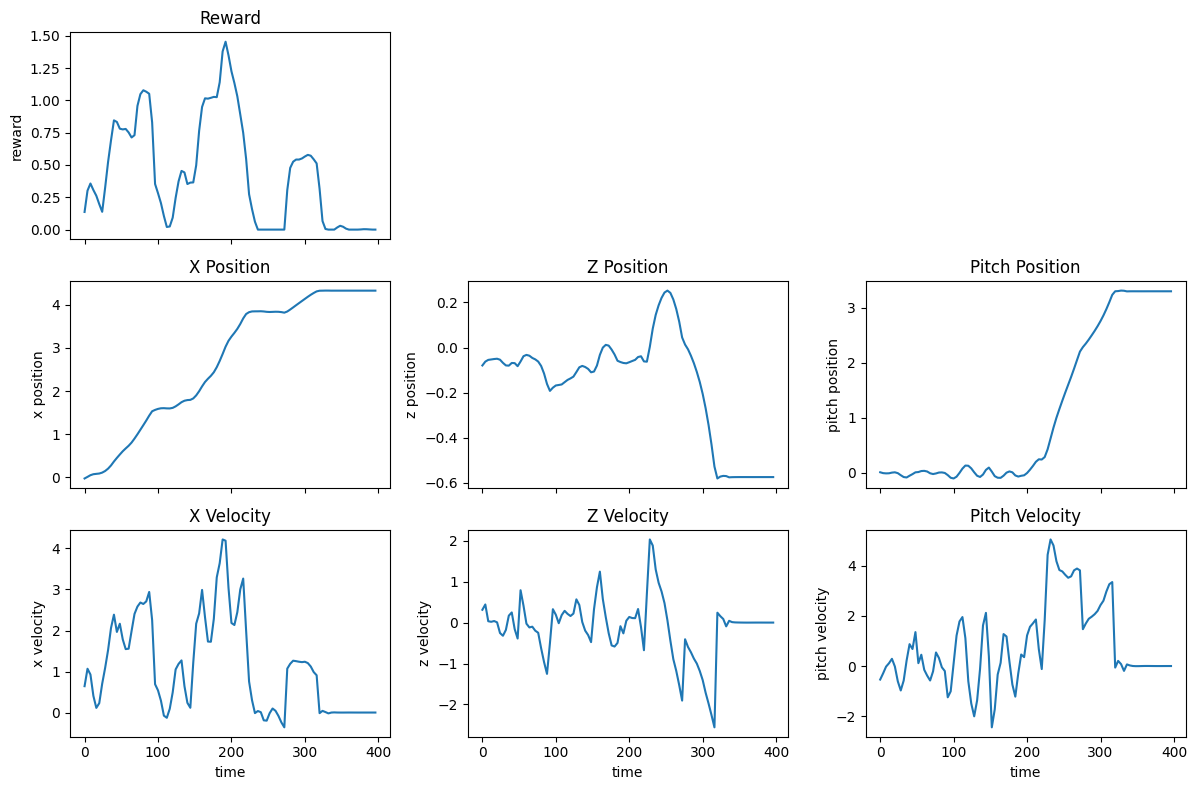

In [20]:
#@title {vertical-output: true}
import copy
import matplotlib.pyplot as plt

random_state = np.random.RandomState(42)
np.random.seed(42)
env = MPC_ENV_GT(suite.load('cheetah', 'run', task_kwargs={'random': random_state}))

# Set simulation duration and calculate number of steps
duration = 4.0  # seconds
num_steps = int(duration / env.control_timestep)

# ================================
# Do NOT change - We are only using CPU, and GPU is not allowed.
device = torch.device("cpu")
# ================================


# ================================
# MPC INSTANTIATION
mpc_agent = CVAEAgent('act_normalizer.pt','cvae_mlp_policy.pth', prediction_horizon=10, latent_dim=8)

rewards = []
ticks = []
action_sequence = []
env.reset()
active_force_until = -1
# Main simulation loop
for step in range(num_steps):
    # Plan: Get best action sequence via MPC and take first action
    current_state = env.get_state()

    if len(action_sequence) == 0:
      action_sequence = mpc_agent.plan(current_state)[:mpc_agent.execution_horizon]
    action, action_sequence = action_sequence[0], action_sequence[1:]

    # Execute: Apply action to environment
    reward = env.step(action,True)

    # Record: Collect data from this step
    rewards.append(reward)
    ticks.append(step)

    # Print progress every 10 steps
    if step % 10 == 0:
        print(f"Step {step}/{num_steps}, total reward: {sum(rewards):.2f}, avg reward: {np.mean(rewards):.4f}")

frames, qposs, qvels = env.get_log()
print(f"{len(frames)} frames, total reward: {sum(rewards):.2f}, avg reward: {np.mean(rewards):.4f}")
visualize_log(ticks, rewards, frames, qposs, qvels)

env.close()
# Display video of the cheetah running
show_video(frames, fps=25)


## **Grading and Evaluation for Part 2**

Your trained policy will be evaluated over **100 independent episodes**, each consisting of a **4-second rollout**.

In each episode:

- The environment is initialized with a different random seed.
- Your controller generates actions using the learned policy.
- The accumulated reward over the episode is recorded.

---

### Stability Penalty

If the cheetah falls during an episode (i.e., the torso pitch angle exceeds the threshold):

- The reward for that episode will be **penalized**.
- The number of such failures will also be recorded.

---

### Final Score

After all 100 episodes:

- The **average penalized reward** is computed.
- Your final score is determined based on the following thresholds:
  - Average reward ≥ 100 → **3 points**
  - Average reward ≥ 80 → **2 points**
  - Average reward ≥ 40 → **1 point**
  - Average reward < 40 → **0 points**

---

This evaluation emphasizes not only performance but also **robustness across different initial conditions**. Controllers that are unstable or sensitive to distribution shifts will receive lower scores.

Except for the line:

    mpc_agent = CVAEAgent('act_normalizer.pt','cvae_mlp_policy.pth')

you are **not allowed to modify any other code in the evaluation cell**.

In [21]:
#@title{vertical-output: true}
import copy
import time
import matplotlib.pyplot as plt


# Set simulation duration and calculate number of steps
duration = 4.0  # seconds

# Instantiate your Agent controller
# but do NOT modify anything else in this cell.
# ================================
# YOUR CODE GOES HERE ONLY
mpc_agent = CVAEAgent('act_normalizer.pt','cvae_mlp_policy.pth', prediction_horizon=10, latent_dim=8)
# ================================

rewards = []
flipped_count = 0

for i in range(100):

  random_state = np.random.RandomState(i+200)
  np.random.seed(i)
  env = MPC_ENV_GT(suite.load('cheetah', 'run', task_kwargs={'random': random_state}))
  env.reset()

  num_steps = int(duration / env.control_timestep)
  reward = 0.0
  flipped = False

  action_sequence = []
  for step in range(num_steps):
      current_state = env.get_state()

      # ---- Fall detection (pitch angle) ----
      if abs(current_state[2]) > np.pi / 2:
          flipped = True

      if len(action_sequence) == 0:
        action_sequence = mpc_agent.plan(current_state)[:mpc_agent.execution_horizon]
      action, action_sequence = action_sequence[0], action_sequence[1:]
      r = env.step(action)

      reward += r

  env.close()
  if flipped:
    reward = reward/2.0
    flipped_count += 1
  else:
    reward = reward
  print(f"Episode {i+1} reward: {reward:.2f}", flipped)
  rewards.append(reward)

avg_reward = np.mean(rewards)
print(f"Average penalized reward: {avg_reward:.2f} with {str(flipped_count)} times flipping")

# Reward score
if avg_reward >= 100:
    final_score_part2 = 3
elif avg_reward >= 80:
    final_score_part2 = 2
elif avg_reward >= 40:
    final_score_part2 = 1
else:
    final_score_part2 = 0

print(f"Score for Part2: {final_score_part2}/3")


Normalizer loaded from act_normalizer.pt
Model loaded from cvae_mlp_policy.pth  (params: 1,143,884)
Episode 1 reward: 56.83 True
Episode 2 reward: 96.85 False
Episode 3 reward: 46.72 True
Episode 4 reward: 33.15 True
Episode 5 reward: 29.47 True
Episode 6 reward: 134.77 False
Episode 7 reward: 42.88 True
Episode 8 reward: 55.02 True
Episode 9 reward: 49.59 True
Episode 10 reward: 79.94 False
Episode 11 reward: 20.24 True
Episode 12 reward: 158.33 False
Episode 13 reward: 75.56 False
Episode 14 reward: 32.00 True
Episode 15 reward: 18.65 True
Episode 16 reward: 157.22 False
Episode 17 reward: 92.62 False
Episode 18 reward: 57.83 True
Episode 19 reward: 141.92 False
Episode 20 reward: 82.09 False
Episode 21 reward: 83.18 False
Episode 22 reward: 55.32 True
Episode 23 reward: 23.85 True
Episode 24 reward: 42.71 True
Episode 25 reward: 32.68 True
Episode 26 reward: 79.58 True
Episode 27 reward: 32.94 True
Episode 28 reward: 32.62 True
Episode 29 reward: 55.45 True
Episode 30 reward: 26.87 

# **Total Score Calculation**

In [22]:
# ================================
# DO NOT MODIFY THIS CELL
# ================================
print(f"Final Score: {final_score_part1 + final_score_part2}/5")


Final Score: 3/5


# **A Note on ACT (Action Chunking with Transformers)**

ACT, introduced in *Learning Fine-Grained Bimanual Manipulation with Low-Cost Hardware*, is a transformer-based imitation learning framework that models a **distribution over action sequences (action chunks)** rather than predicting a single action at each timestep. This design helps reduce compounding errors and allows the policy to capture multi-modal expert behaviors.

The following description simplifies certain components of ACT-style implementation for clarity and usability while closely following [the original design](https://github.com/tonyzhaozh/act/tree/main).

---

## Architecture Overview

ACT follows a **CVAE-style structure** consisting of:

- An **Encoder** that infers a latent variable $z$
- A **Decoder** that generates an action sequence conditioned on the observation and $z$

### Encoder (Transformer-based Posterior)

The encoder takes as input:

- A sequence of observations
- A sequence of actions (from demonstrations)

These inputs are first projected into a shared embedding space and concatenated into a single sequence. A learnable **CLS token** is prepended to summarize the entire sequence. Positional encoding is added to preserve temporal order.

The sequence is then processed by a **Transformer Encoder**, and the output corresponding to the CLS token is used as a global representation. From this representation, the model predicts:

- Mean $\mu$
- Log-variance $\log \sigma^2$

which define the latent distribution:

$z \sim \mathcal{N}(\mu, \sigma^2)$

This allows the model to capture the variability of expert demonstrations.

---

### Decoder (Transformer with Cross-Attention)

The decoder generates an action sequence conditioned on:

- The observation sequence
- The latent variable $z$

First, observations are encoded into a set of **memory tokens** using a Transformer encoder. The latent variable $z$ is projected into the same embedding space and injected into this memory.

The decoder then uses a set of **learned query embeddings**, where each query corresponds to one timestep in the predicted action horizon. These queries attend to the observation memory through **cross-attention**, producing a sequence of latent features that are finally mapped to actions.

This design allows the model to predict all future actions in parallel, rather than autoregressively.

---

## Key Design Ideas

- **Action Chunking**: Predict multiple future actions at once to reduce error accumulation.
- **Latent Variable Modeling**: Capture multi-modality in demonstrations.
- **Parallel Decoding**: Improves efficiency compared to autoregressive models.
- **Transformer Architecture**: Enables rich temporal and contextual modeling.

---

## Latent Variable Injection (z Embedding)

In the original ACT implementation, the latent variable $z$ is typically **concatenated with the observation representation** before decoding. However, this is not the only way to incorporate latent information.

More recent and commonly used alternatives include:

- **Additive Injection**  
  Project $z$ into the embedding space and add it to observation or query embeddings.

- **Conditioning via Queries**  
  Add $z$ directly to the action query embeddings, allowing it to influence each predicted timestep.

- **Feature-wise Modulation (FiLM)**  
  Use $z$ to scale and shift intermediate features:
  $h' = \gamma(z) \cdot h + \beta(z)$

- **Cross-Attention to Latent Token**  
  Let the decoder attend to a latent token derived from $z$, similar to memory attention.

Different choices may lead to different performance and stability trade-offs. In practice, all of these methods aim to ensure that the decoder is properly conditioned on the latent variable.

---

## Practical Considerations

Transformer-based policies such as ACT are typically:

- More expressive than MLP-based models
- More computationally expensive
- More data-hungry

For this assignment, the task is relatively simple. In our experiments, even with significantly longer training time, ACT only achieves **slightly better performance** than an MLP-based CVAE.

However, ACT remains a powerful approach, and you are encouraged to experiment with it if you are interested in more advanced sequence modeling techniques.